# Assignment: Xarray Fundamentals with Atmospheric Radiation Data

In [187]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)
%config InlineBackend.figure_format = 'retina'

In [7]:
import pooch
fname = pooch.retrieve(
    'http://ldeo.columbia.edu/~danielmw/CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc',
    known_hash=None,  downloader=pooch.HTTPDownloader(verify=False)
)
print(fname)

/home/xm2357/.cache/pooch/a379a4cf37bf10809e636b0809c1c88b-CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc


## 1) Opening data and examining metadata
### 1.1) Open the dataset and display its contents

In [8]:
da = xr.open_dataset('/home/xm2357/.cache/pooch/a379a4cf37bf10809e636b0809c1c88b-CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc')

In [9]:
da

<xarray.Dataset> Size: 737MB
Dimensions:                      (lon: 360, time: 203, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (time, lat, lon) float32 53MB ...
    toa_lw_all_mon               (time, lat, lon) float32 53MB ...
    toa_net_all_mon              (time, lat, lon) float32 53MB ...
    toa_sw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_lw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_net_clr_mon              (time, lat, lon) float32 53MB ...
    ...                           ...
    toa_cre_net_mon              (time, lat, lon) float32 53MB ...
    solar_mon                    (time, lat, lon) float32 53MB ...
    cldarea_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldpress_total_daynight_mon  (time, lat, lon) float32 53MB ...
    cldtemp_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldtau_total_day_mon         (time, lat, lon) float32 53MB ...
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

### 1.2) Print out the long_name attribute of each variable
#### Print variable: long name for each variable. Format the output so that the start of the long name attributes are aligned.

In [14]:
for var in da.data_vars:
    print(var,':',da[var].attrs.get('long_name'))

toa_sw_all_mon : Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions
toa_lw_all_mon : Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions
toa_net_all_mon : Top of The Atmosphere Net Flux, Monthly Means, All-Sky conditions
toa_sw_clr_mon : Top of The Atmosphere Shortwave Flux, Monthly Means, Clear-Sky conditions
toa_lw_clr_mon : Top of The Atmosphere Longwave Flux, Monthly Means, Clear-Sky conditions
toa_net_clr_mon : Top of The Atmosphere Net Flux, Monthly Means, Clear-Sky conditions
toa_cre_sw_mon : Top of The Atmosphere Cloud Radiative Effects Shortwave Flux, Monthly Means
toa_cre_lw_mon : Top of The Atmosphere Cloud Radiative Effects Longwave Flux, Monthly Means
toa_cre_net_mon : Top of The Atmosphere Cloud Radiative Effects Net Flux, Monthly Means
solar_mon : Incoming Solar Flux, Monthly Means
cldarea_total_daynight_mon : Cloud Area Fraction, Monthly Means, Daytime-and-Nighttime conditions
cldpress_total_daynight_mon : Cloud Effective Pressure

In [16]:
max_len = max(len(var) for var in da.data_vars)
max_len

27

In [18]:
for var in da.data_vars:
    print(f"{var:28}:{da[var].attrs.get('long_name')}")

toa_sw_all_mon              :Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions
toa_lw_all_mon              :Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions
toa_net_all_mon             :Top of The Atmosphere Net Flux, Monthly Means, All-Sky conditions
toa_sw_clr_mon              :Top of The Atmosphere Shortwave Flux, Monthly Means, Clear-Sky conditions
toa_lw_clr_mon              :Top of The Atmosphere Longwave Flux, Monthly Means, Clear-Sky conditions
toa_net_clr_mon             :Top of The Atmosphere Net Flux, Monthly Means, Clear-Sky conditions
toa_cre_sw_mon              :Top of The Atmosphere Cloud Radiative Effects Shortwave Flux, Monthly Means
toa_cre_lw_mon              :Top of The Atmosphere Cloud Radiative Effects Longwave Flux, Monthly Means
toa_cre_net_mon             :Top of The Atmosphere Cloud Radiative Effects Net Flux, Monthly Means
solar_mon                   :Incoming Solar Flux, Monthly Means
cldarea_total_daynight_mon  :C

### 2) Basic reductions, arithmetic, and plotting
#### 2.1) Calculate the time-mean of the entire dataset

In [19]:
time_mean = da.mean(dim='time')
time_mean

<xarray.Dataset> Size: 4MB
Dimensions:                      (lon: 360, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (lat, lon) float32 259kB 122.3 122.3 ... 104.4
    toa_lw_all_mon               (lat, lon) float32 259kB 141.1 141.1 ... 194.1
    toa_net_all_mon              (lat, lon) float32 259kB -91.29 ... -126.3
    toa_sw_clr_mon               (lat, lon) float32 259kB 119.9 119.9 ... 89.47
    toa_lw_clr_mon               (lat, lon) float32 259kB 140.2 140.2 ... 200.4
    toa_net_clr_mon              (lat, lon) float32 259kB -88.03 ... -117.6
    ...                           ...
    toa_cre_net_mon              (lat, lon) float32 259kB -3.253 ... -8.651
    solar_mon                    (lat, lon) float32 259kB 172.1 172.1 ... 172.3
    cldarea_total_daynight_mon   (lat, lon) float32 259kB 51.52 51.52 ... 78.93
    cldpress_total_daynight_mon  (lat, lon) float32 259kB 486.5 486.5 ... 766.9
    cldtemp_total_daynight_mon   (lat, lon) float32 259kB 225.2 225.2 ... 247.9
    cldtau_total_day_mon         (lat, lon) float32 259kB 4.158 4.158 ... 4.821

#### 2.2) From this, make a 2D plot of the the time-mean Top of Atmosphere (TOA) Longwave, Shortwave, and Incoming Solar Radiation
#### (Use “All-Sky” conditions) Note the sign conventions on each variable.

Text(0.5, 1.0, 'TOA Longwave Flux, Monthly Means, All-Sky conditions')

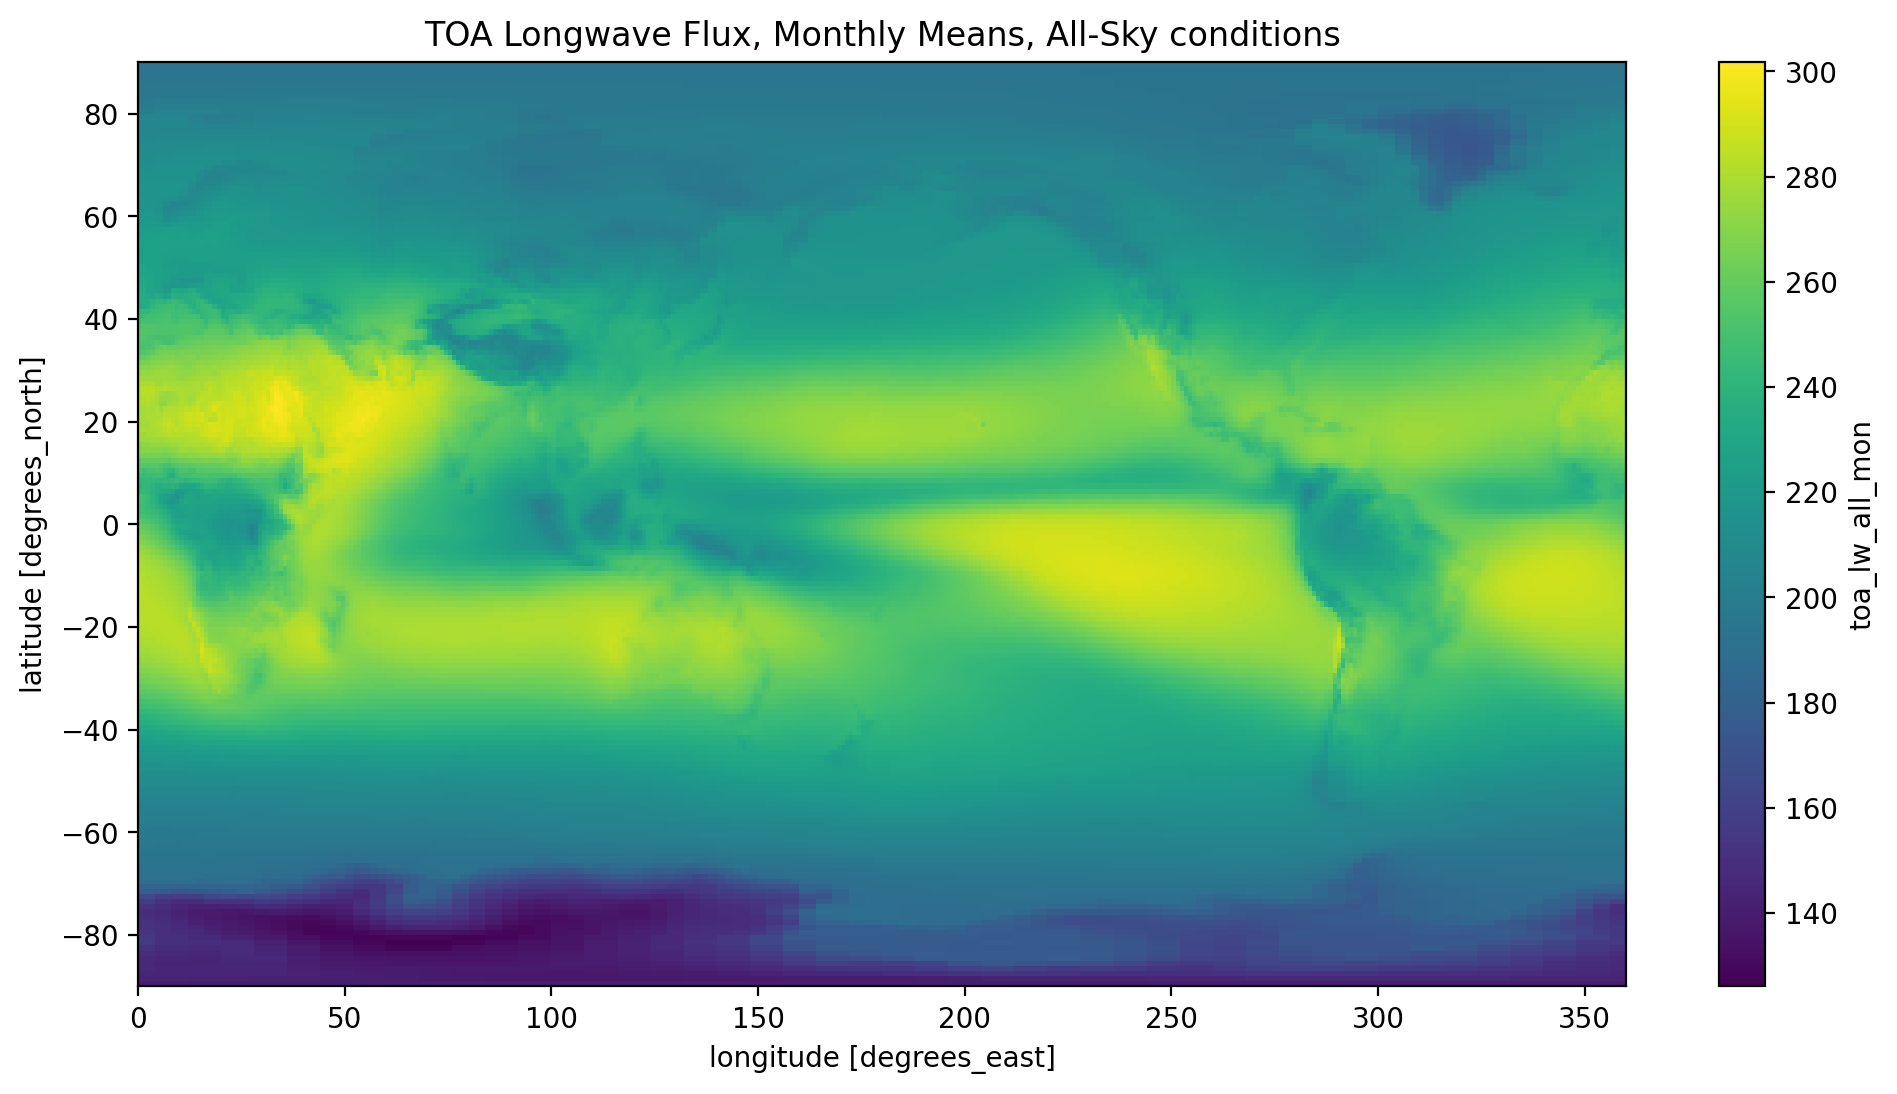

In [43]:
time_mean['toa_lw_all_mon'].plot()
plt.title('TOA Longwave Flux, Monthly Means, All-Sky conditions')

Text(0.5, 1.0, 'TOA Shortwave Flux, Monthly Means, Clear-Sky conditions')

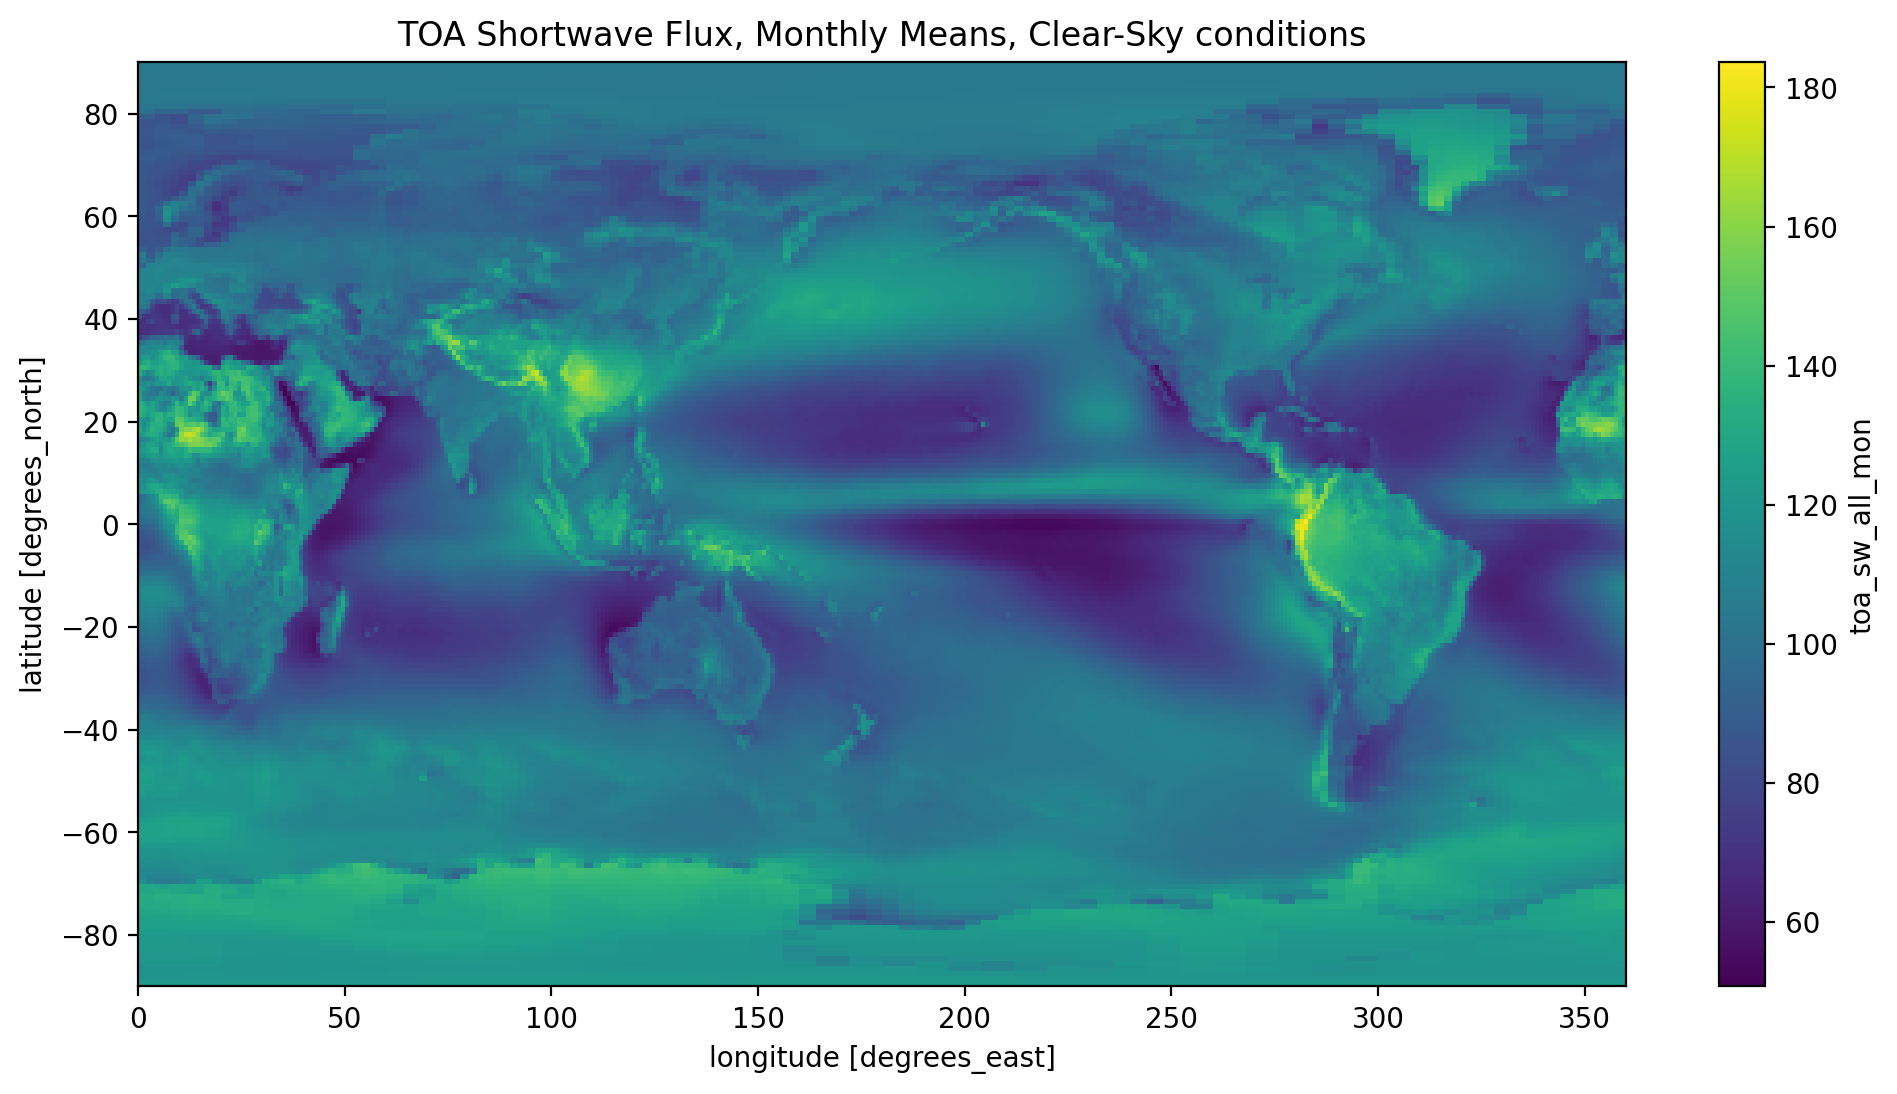

In [42]:
time_mean['toa_sw_all_mon'].plot()
plt.title('TOA Shortwave Flux, Monthly Means, Clear-Sky conditions')

Text(0.5, 1.0, 'Incoming Solar Flux, Monthly Means')

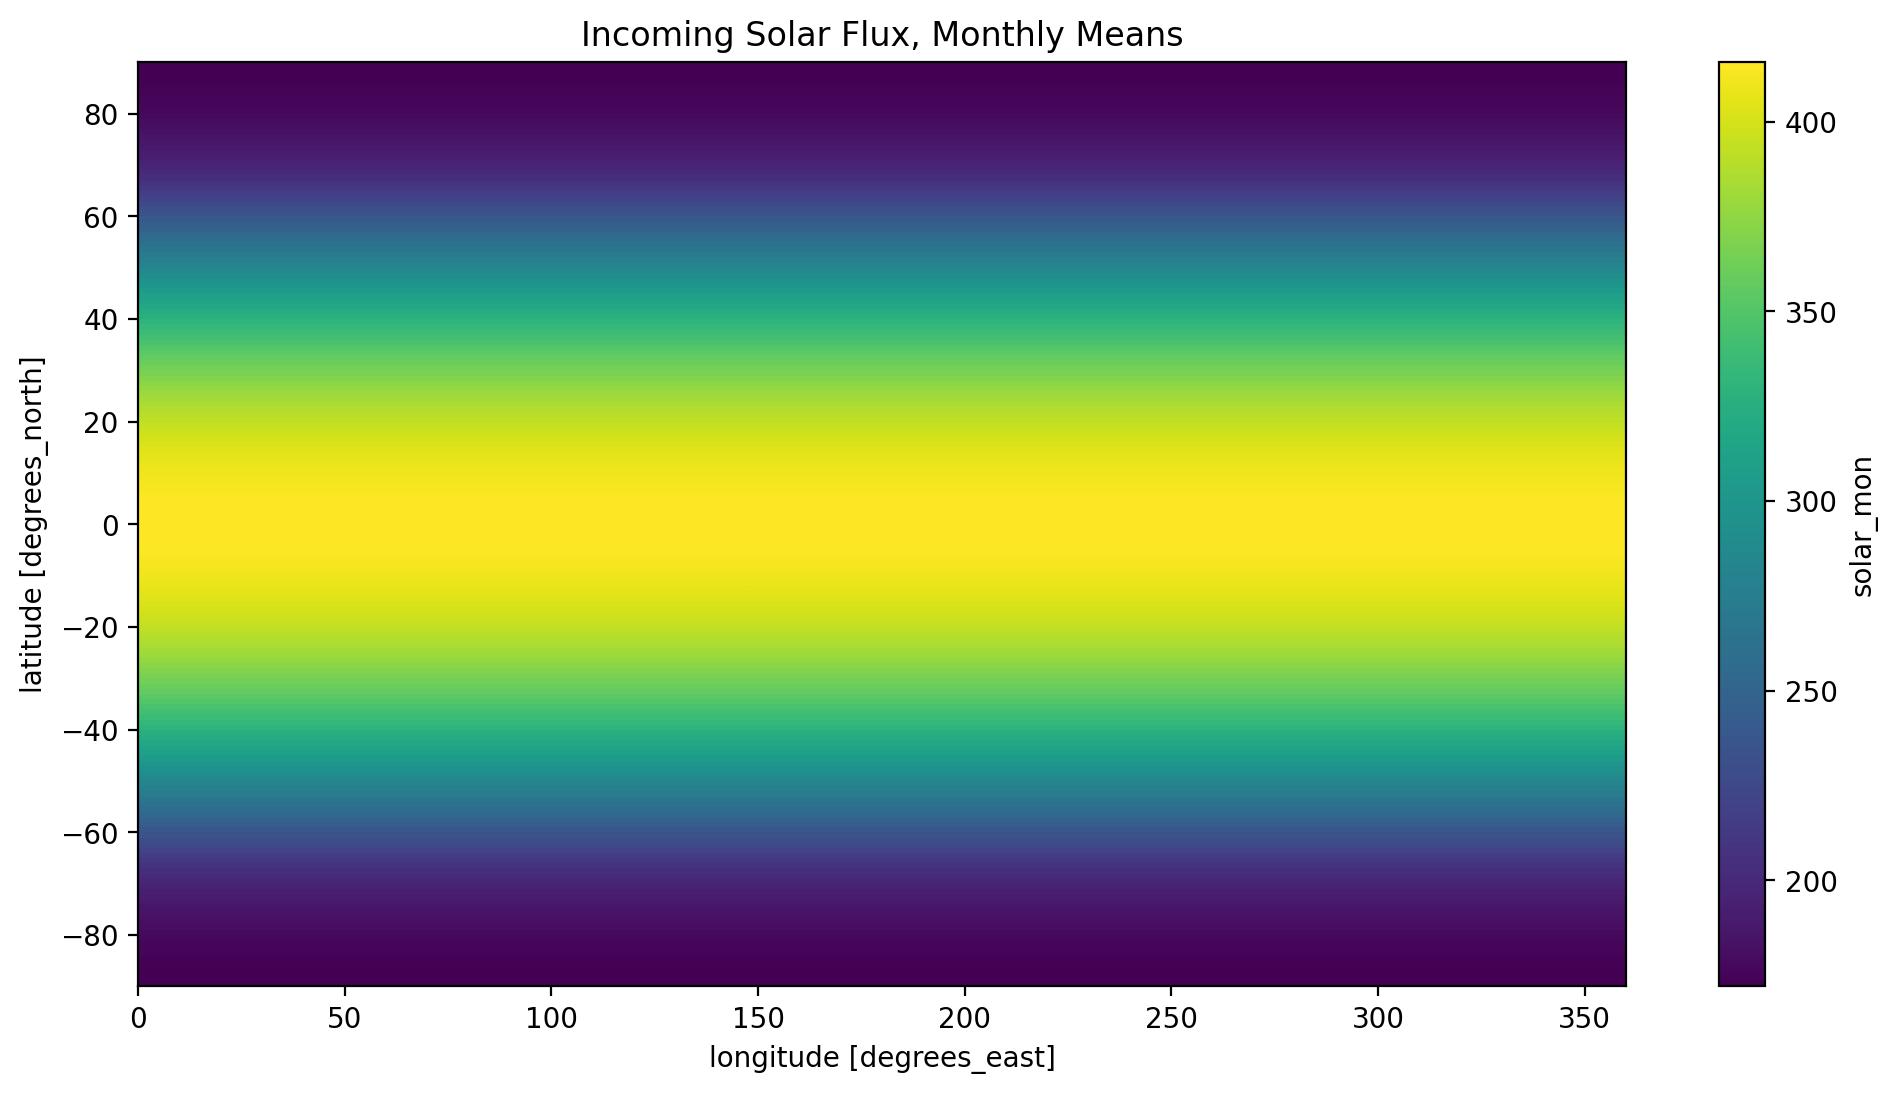

In [44]:
time_mean['solar_mon'].plot()
plt.title('Incoming Solar Flux, Monthly Means')

#### 2.3) Add up the three variables above and verify (visually) that they are equivalent to the TOA net flux
You have to pay attention to and think carefully about the sign conventions (positive or negative) for each variable in order for the variables to sum to the right TOA net flux. Refer to the NASA figure at the top of the page to understand incoming and outgoing radiation.

In [26]:
# net= solar_mon - toa_lw_all - toa_sw_all_mon
net=time_mean['solar_mon']- time_mean['toa_lw_all_mon']- time_mean['toa_sw_all_mon']

In [27]:
net # varify: if net = toa_net_all_mon 

<xarray.DataArray (lat: 180, lon: 360)> Size: 259kB
array([[ -91.28788 ,  -91.28788 ,  -91.28788 , ...,  -91.28788 ,
         -91.28788 ,  -91.28788 ],
       [ -91.457016,  -91.457016,  -91.457016, ...,  -91.457016,
         -91.457016,  -91.457016],
       [ -91.82569 ,  -91.82569 ,  -91.82569 , ...,  -91.82569 ,
         -91.82569 ,  -91.82569 ],
       ...,
       [-125.81961 , -125.81961 , -125.81961 , ..., -125.81961 ,
        -125.81961 , -125.81961 ],
       [-125.93743 , -125.93743 , -125.93743 , ..., -125.93743 ,
        -125.93743 , -125.93743 ],
       [-126.26445 , -126.26445 , -126.26445 , ..., -126.26445 ,
        -126.26445 , -126.26445 ]], dtype=float32)
Coordinates:
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5

Text(0.5, 1.0, 'Net Flux From Datasets')

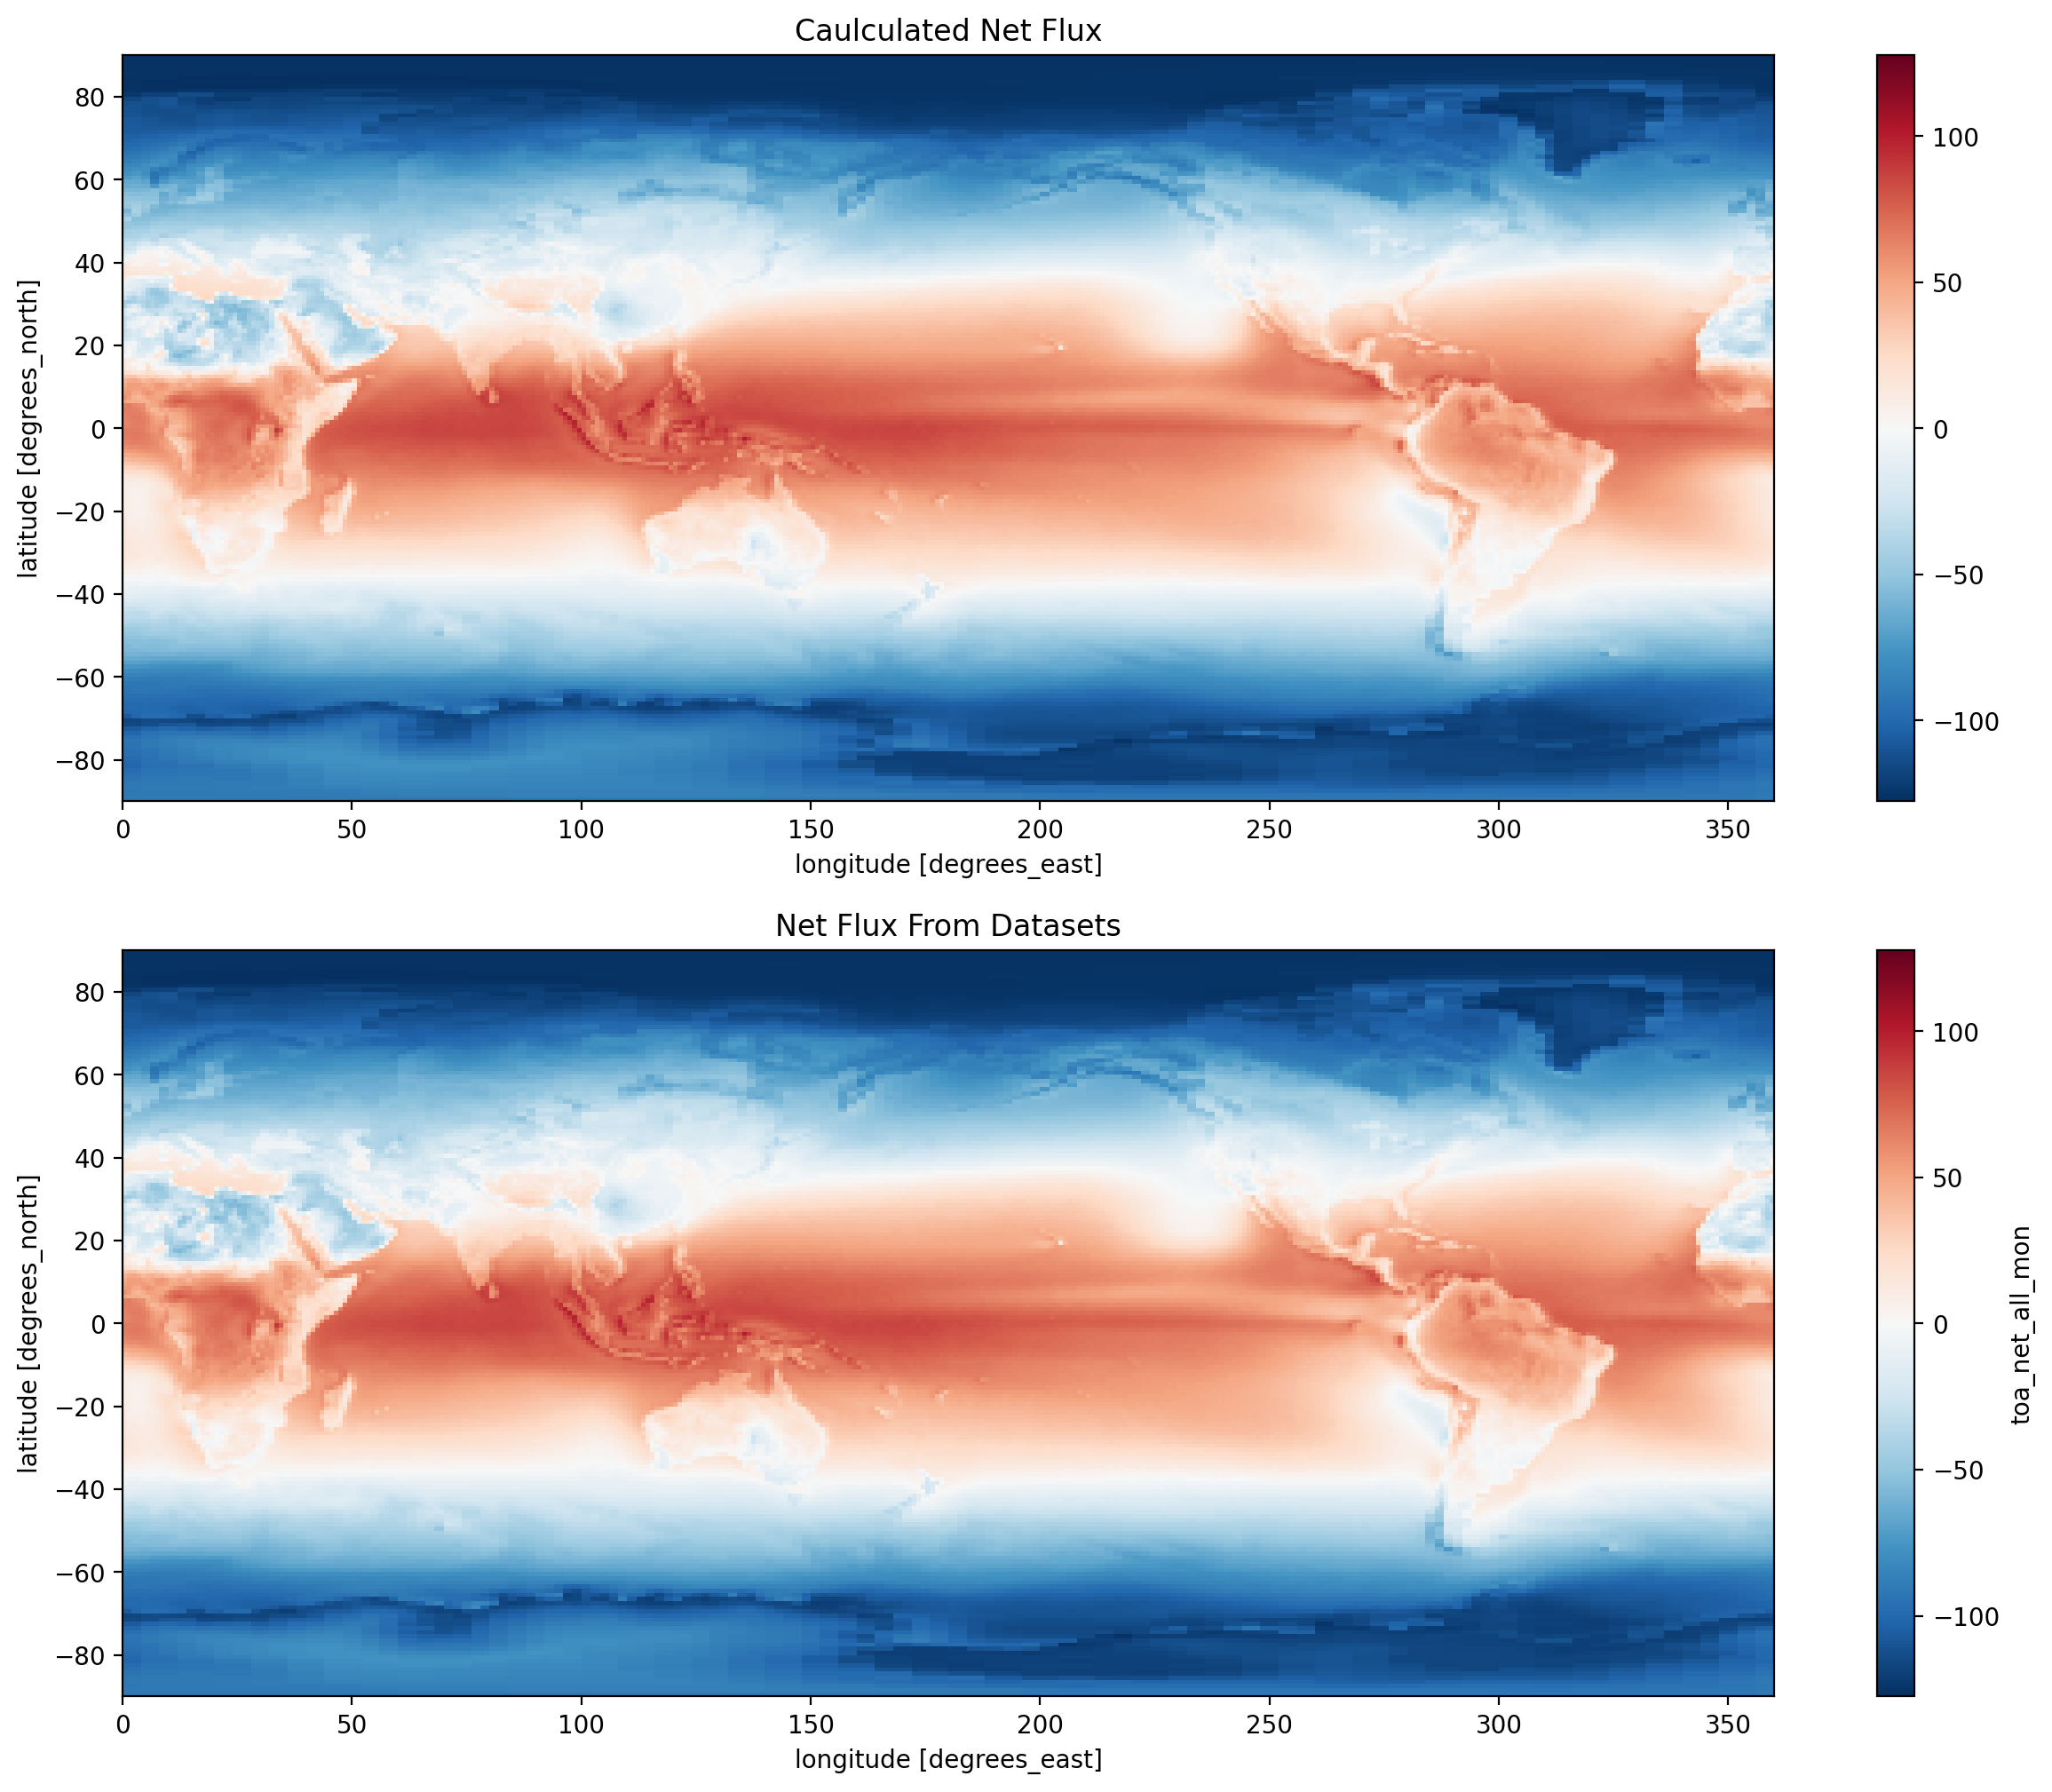

In [39]:
fig,ax = plt.subplots(2,1,figsize=(15,12))
net.plot(ax=ax[0])
ax[0].set_title('Caulculated Net Flux')
time_mean['toa_net_all_mon'].plot(ax= ax[1])
ax[1].set_title('Net Flux From Datasets')

In [ ]:
# from these plots, net = toa_net_all_mon 

### 3) Mean and weighted mean
#### 3.1) Calculate the global (unweighted) mean of TOA net radiation
Since the Earth is approximately in radiative balance, the net TOA radiation should be zero. But taking the naive mean from this dataset, you should find a number far from zero. Why?
The answer is that each “pixel” or “grid point” of this dataset does not represent an equal area of Earth’s surface. So naively taking the mean, i.e. giving equal weight to each point, gives the wrong answer.
On a lat / lon grid, the relative area of each grid point is proportional to cos(λ)

In [47]:
TOA_net_mean = da['toa_net_all_mon'].mean()
TOA_net_mean

<xarray.DataArray 'toa_net_all_mon' ()> Size: 4B
array(-28.729012, dtype=float32)

#### 3.2) Create a weight array proportional to cos(λ)
Think carefully a about radians vs. degrees

In [53]:
weight = np.cos(np.deg2rad(da.lat))
weight

<xarray.DataArray 'lat' (lat: 180)> Size: 720B
array([0.00872656, 0.02617699, 0.04361945, 0.06104851, 0.07845908,
       0.09584576, 0.11320324, 0.13052624, 0.14780948, 0.16504757,
       0.18223551, 0.19936794, 0.21643965, 0.23344542, 0.25037998,
       0.26723838, 0.28401536, 0.30070582, 0.3173047 , 0.33380693,
       0.35020736, 0.3665012 , 0.38268346, 0.3987491 , 0.4146933 ,
       0.43051115, 0.44619778, 0.4617486 , 0.47715878, 0.49242356,
       0.5075384 , 0.5224986 , 0.5372996 , 0.551937  , 0.56640625,
       0.58070296, 0.59482276, 0.6087614 , 0.62251467, 0.6360782 ,
       0.64944804, 0.66262007, 0.67559016, 0.68835455, 0.70090926,
       0.71325046, 0.72537434, 0.7372773 , 0.7489557 , 0.76040596,
       0.77162457, 0.78260815, 0.7933533 , 0.8038569 , 0.8141155 ,
       0.8241262 , 0.83388585, 0.8433914 , 0.85264015, 0.8616291 ,
       0.87035567, 0.87881714, 0.8870108 , 0.89493436, 0.90258527,
       0.9099613 , 0.9170601 , 0.9238795 , 0.9304176 , 0.9366722 ,
       0.9426415 , 0.94832367, 0.95371693, 0.95881975, 0.96363044,
       0.96814764, 0.9723699 , 0.976296  , 0.9799247 , 0.9832549 ,
       0.9862856 , 0.9890159 , 0.9914449 , 0.9935719 , 0.9953962 ,
       0.9969173 , 0.9981348 , 0.99904823, 0.99965733, 0.9999619 ,
       0.9999619 , 0.99965733, 0.99904823, 0.9981348 , 0.9969173 ,
       0.9953962 , 0.9935719 , 0.9914449 , 0.9890159 , 0.9862856 ,
       0.9832549 , 0.9799247 , 0.976296  , 0.9723699 , 0.96814764,
       0.96363044, 0.95881975, 0.95371693, 0.94832367, 0.9426415 ,
       0.9366722 , 0.9304176 , 0.9238795 , 0.9170601 , 0.9099613 ,
       0.90258527, 0.89493436, 0.8870108 , 0.87881714, 0.87035567,
       0.8616291 , 0.85264015, 0.8433914 , 0.83388585, 0.8241262 ,
       0.8141155 , 0.8038569 , 0.7933533 , 0.78260815, 0.77162457,
       0.76040596, 0.7489557 , 0.7372773 , 0.72537434, 0.71325046,
       0.70090926, 0.68835455, 0.67559016, 0.66262007, 0.64944804,
       0.6360782 , 0.62251467, 0.6087614 , 0.59482276, 0.58070296,
       0.56640625, 0.551937  , 0.5372996 , 0.5224986 , 0.5075384 ,
       0.49242356, 0.47715878, 0.4617486 , 0.44619778, 0.43051115,
       0.4146933 , 0.3987491 , 0.38268346, 0.3665012 , 0.35020736,
       0.33380693, 0.3173047 , 0.30070582, 0.28401536, 0.26723838,
       0.25037998, 0.23344542, 0.21643965, 0.19936794, 0.18223551,
       0.16504757, 0.14780948, 0.13052624, 0.11320324, 0.09584576,
       0.07845908, 0.06104851, 0.04361945, 0.02617699, 0.00872656],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Attributes:
    long_name:      latitude
    standard_name:  latitude
    units:          degrees_north
    valid_range:    [-90.  90.]

#### 3.3) Redo your global mean TOA net radiation calculation with this weight factor
This time around, you should have found something much closer to zero. 

In [57]:
weighted_da = da.weighted(weight)
weighted_da.mean().toa_net_all_mon

<xarray.DataArray 'toa_net_all_mon' ()> Size: 4B
array(0.8780852, dtype=float32)

In [62]:
da['toa_net_all_mon'].weighted(weight).mean() # this works as well

<xarray.DataArray 'toa_net_all_mon' ()> Size: 4B
array(0.8780852, dtype=float32)

#### Ask a climate scientist what the net energy imbalance of Earth due to global warming is estimated to be. Do you think our calculation is precise enough to detect this?
Earth energy imbalance is about 1 W/m².I think this calculation is good for checking the large-scale energy budget,but may not be very precise. 

#### 3.4) Now that you have a weight factor, verify that the TOA incoming solar, outgoing longwave, and outgoing shortwave approximately match up with infographic shown in the first cell of this assignment

In [63]:
da['toa_sw_all_mon'].weighted(weight).mean()

<xarray.DataArray 'toa_sw_all_mon' ()> Size: 4B
array(99.13806, dtype=float32)

In [64]:
da['toa_lw_all_mon'].weighted(weight).mean()

<xarray.DataArray 'toa_lw_all_mon' ()> Size: 4B
array(240.26692, dtype=float32)

In [65]:
da['solar_mon'].weighted(weight).mean()

<xarray.DataArray 'solar_mon' ()> Size: 4B
array(340.28326, dtype=float32)

#### These values are approximately consistent with the Earth energy budget infographic:
incoming solar(340.3) ≈ outgoing shortwave(99.1) + outgoing longwave(240.3)

### 4) Meridional Heat Transport Calculation

#### 4.1) calculate the pixel area using this formula and create a 2D (lon, lat) DataArray for it

In [71]:
R = 6371

d_lambda = np.deg2rad(1)
d_phi = np.deg2rad(1)

r_squared = R**2
dA = r_squared * np.cos(np.deg2rad(da.lat)) * d_lambda * d_phi

# ones_like
ones_array = xr.ones_like(da)
pixel_a = ones_array * dA
total_pixel_a = pixel_a.sum(dim=['lat','lon'])

#### Verify that the sum of all the pixels equals the Earth’s true surface area as evaluated using the formula for the area of a sphere

In [73]:
earth_surface= 4* np.pi * r_squared
earth_surface

510064471.90978825

In [75]:
total_pixel_a.toa_sw_all_mon[0].values

array(5.1007095e+08)

#### 4.2) Calculate and plot the total amount of net radiation in each 1-degree latitude band
Multiplying the pixel area from above with the radiative flux gives you the total amount of radiation absorbed in each pixel in W.
Label with correct units.

In [188]:
total_net_r = dA * da.toa_net_all_mon

Text(0.5, 0, 'Radiation in Watts (W)')

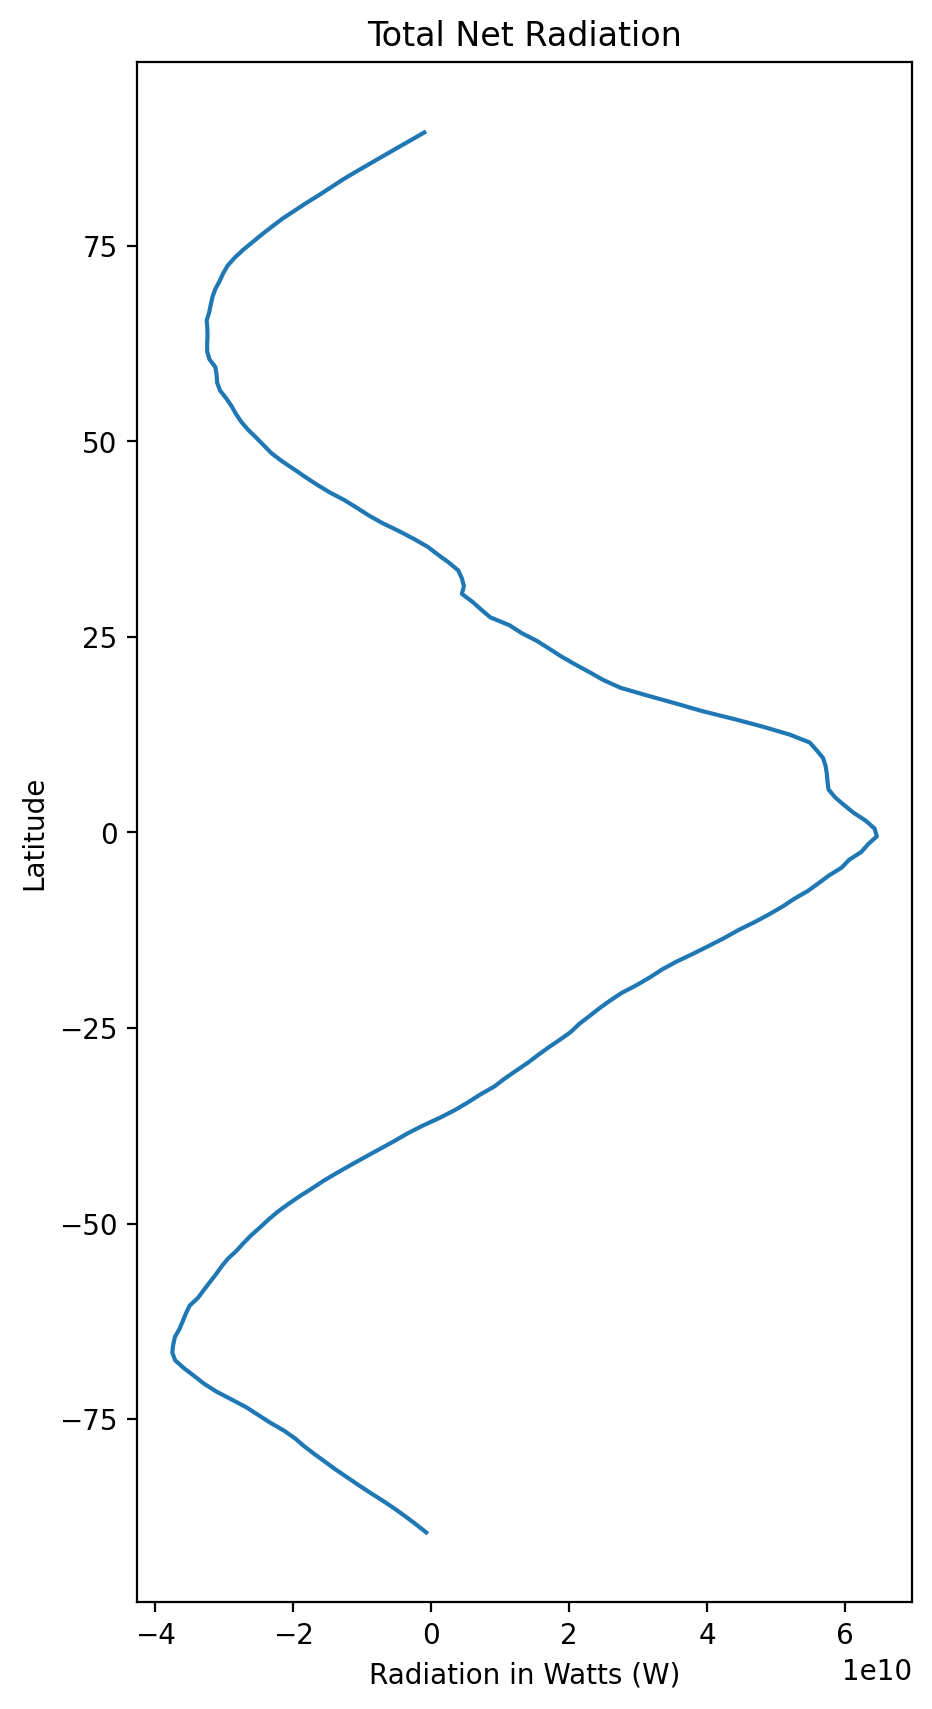

In [113]:
plt.figure(figsize=(5,10))
total_net_r.sum(dim=['lon','time']).plot(y='lat',label='Net Radiation in Watts')
plt.title('Total Net Radiation')
plt.ylabel('Latitude')
plt.xlabel('Radiation in Watts (W)')

#### 4.3) Plot the cumulative sum of the total amount of net radiation as a function of latitude

In [122]:
total = total_net_r.sum(dim=['lon','time'])
cumsum_total = total.cumsum()

Text(0, 0.5, 'Heat Transport (PW)')

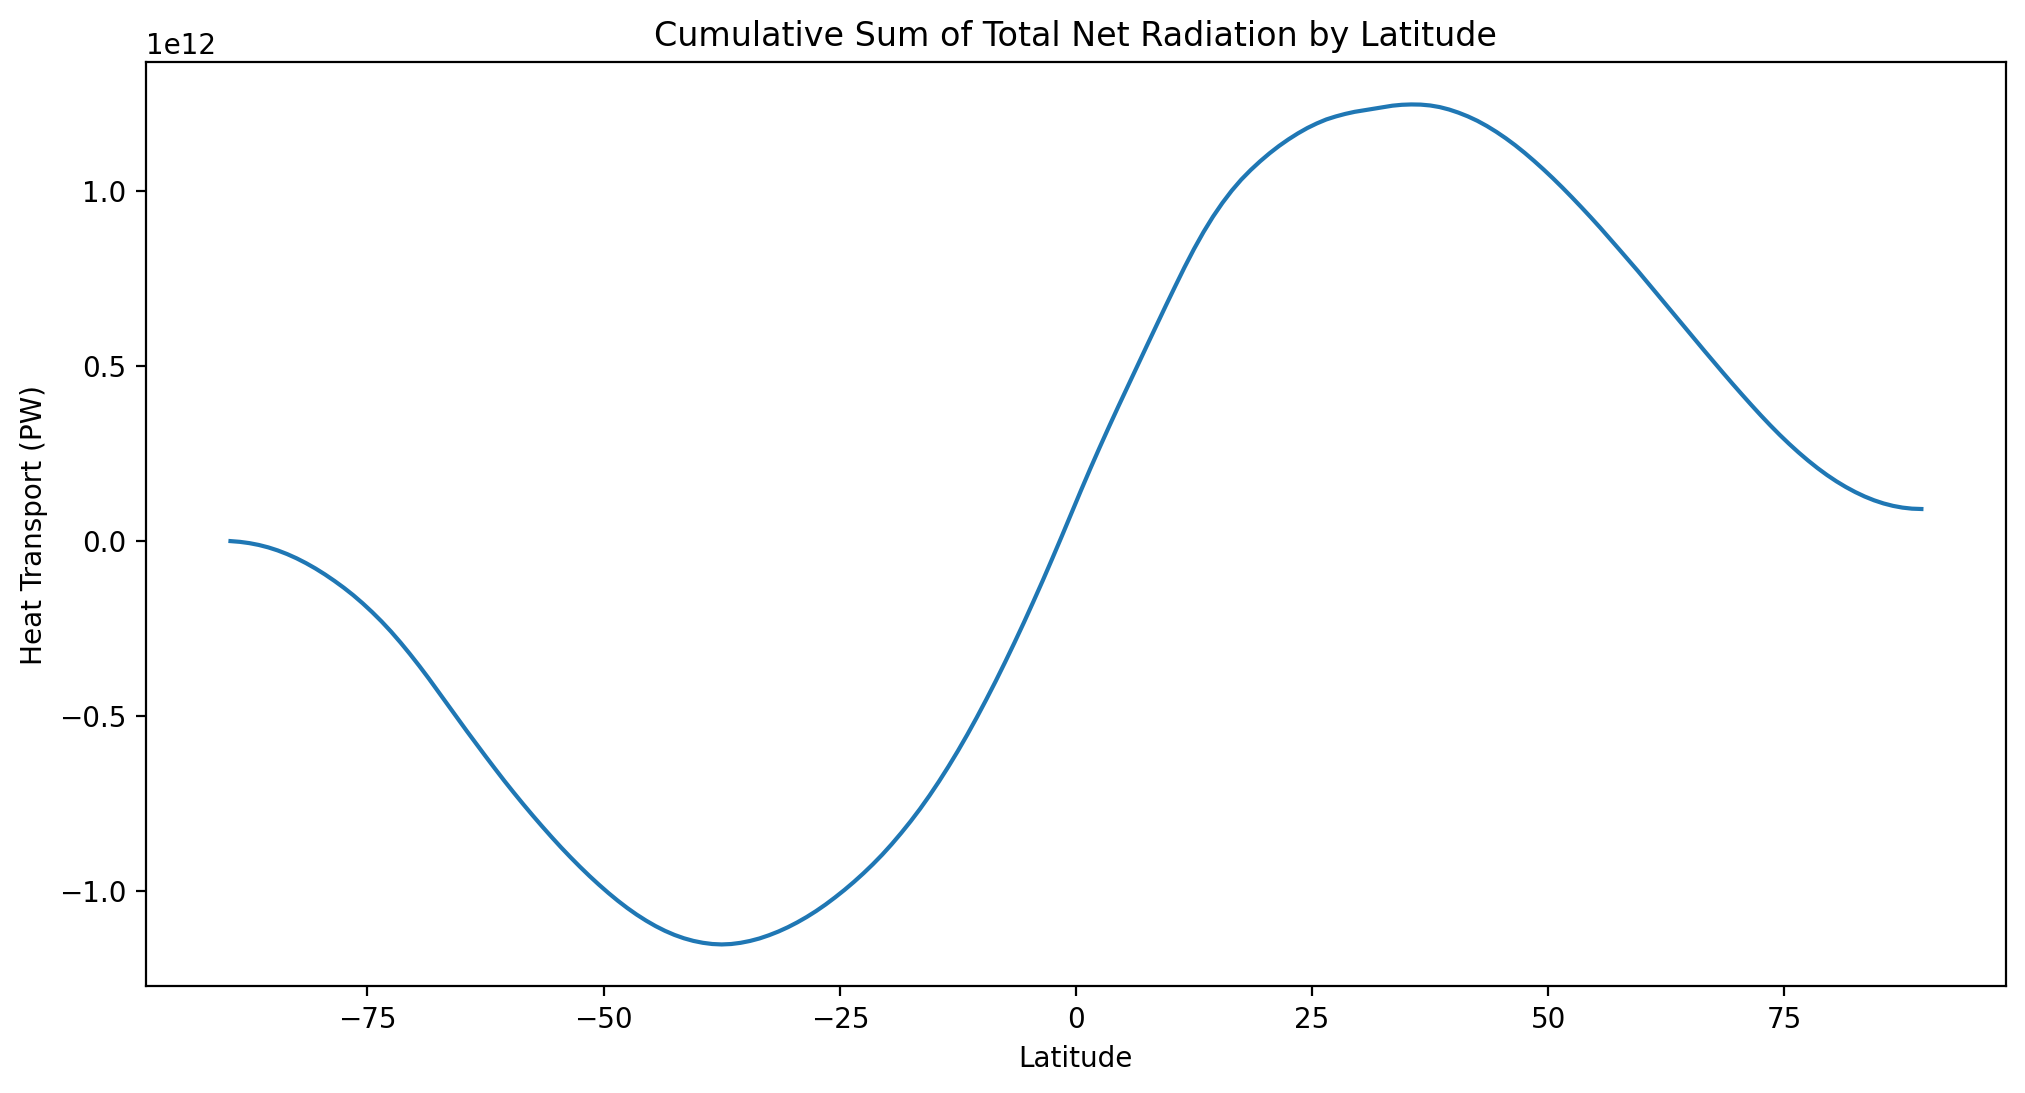

In [125]:
cumsum_total.plot()
plt.title('Cumulative Sum of Total Net Radiation by Latitude')
plt.xlabel('Latitude')
plt.ylabel('Heat Transport (PW)')

### 5) Selecting and Merging Data
#### 5.1) Create a Dataset for each point from the global dataset
Each city should get its own Dataset with the same variables as the one you imported. Find the nearest associated incoming solar radiation and net radiation timeseries at each city.

In [131]:
nyc = da.sel(lon=281,lat=40,method='nearest')
nome = da.sel(lon=195,lat=64,method='nearest')
columbo =da.sel(lon=80,lat=7,method='nearest')
hobart= da.sel(lon=147,lat=-43,method='nearest')

In [133]:
nyc['toa_net_all_mon']

<xarray.DataArray 'solar_mon' (time: 203)> Size: 812B
array([321.4, 402.7, 459. , ..., 188.1, 155.3, 174.9], dtype=float32)
Coordinates:
    lon      float32 4B 281.5
  * time     (time) datetime64[ns] 2kB 2000-03-15 2000-04-15 ... 2017-01-15
    lat      float32 4B 40.5
Attributes:
    long_name:      Incoming Solar Flux, Monthly Means
    standard_name:  Incoming Solar Flux
    CF_name:        toa_incoming_shortwave_flux
    units:          W m-2
    valid_min:            0.00000
    valid_max:            800.000

In [134]:
nyc['solar_mon']

<xarray.DataArray 'solar_mon' (time: 203)> Size: 812B
array([321.4, 402.7, 459. , ..., 188.1, 155.3, 174.9], dtype=float32)
Coordinates:
    lon      float32 4B 281.5
  * time     (time) datetime64[ns] 2kB 2000-03-15 2000-04-15 ... 2017-01-15
    lat      float32 4B 40.5
Attributes:
    long_name:      Incoming Solar Flux, Monthly Means
    standard_name:  Incoming Solar Flux
    CF_name:        toa_incoming_shortwave_flux
    units:          W m-2
    valid_min:            0.00000
    valid_max:            800.000

In [135]:
nome['toa_net_all_mon']

<xarray.DataArray 'toa_net_all_mon' (time: 203)> Size: 812B
array([-127.5  ,  -65.61 ,    3.254, ..., -191.3  , -191.8  , -186.5  ],
      dtype=float32)
Coordinates:
    lon      float32 4B 195.5
  * time     (time) datetime64[ns] 2kB 2000-03-15 2000-04-15 ... 2017-01-15
    lat      float32 4B 64.5
Attributes:
    long_name:      Top of The Atmosphere Net Flux, Monthly Means, All-Sky co...
    standard_name:  TOA Net Flux - All-Sky
    CF_name:        toa_net_downward_flux
    units:          W m-2
    valid_min:           -400.000
    valid_max:            400.000

In [136]:
nome['solar_mon']

<xarray.DataArray 'solar_mon' (time: 203)> Size: 812B
array([173.7  , 302.5  , 416.3  , ...,  28.43 ,   6.045,  17.73 ],
      dtype=float32)
Coordinates:
    lon      float32 4B 195.5
  * time     (time) datetime64[ns] 2kB 2000-03-15 2000-04-15 ... 2017-01-15
    lat      float32 4B 64.5
Attributes:
    long_name:      Incoming Solar Flux, Monthly Means
    standard_name:  Incoming Solar Flux
    CF_name:        toa_incoming_shortwave_flux
    units:          W m-2
    valid_min:            0.00000
    valid_max:            800.000

In [137]:
columbo['toa_net_all_mon']

<xarray.DataArray 'toa_net_all_mon' (time: 203)> Size: 812B
array([68.64, 77.66, 73.28, ..., 40.33, 15.84, 12.46], dtype=float32)
Coordinates:
    lon      float32 4B 80.5
  * time     (time) datetime64[ns] 2kB 2000-03-15 2000-04-15 ... 2017-01-15
    lat      float32 4B 7.5
Attributes:
    long_name:      Top of The Atmosphere Net Flux, Monthly Means, All-Sky co...
    standard_name:  TOA Net Flux - All-Sky
    CF_name:        toa_net_downward_flux
    units:          W m-2
    valid_min:           -400.000
    valid_max:            400.000

In [138]:
columbo['solar_mon']

<xarray.DataArray 'solar_mon' (time: 203)> Size: 812B
array([430.4, 435. , 425.8, ..., 387.6, 372.8, 383.1], dtype=float32)
Coordinates:
    lon      float32 4B 80.5
  * time     (time) datetime64[ns] 2kB 2000-03-15 2000-04-15 ... 2017-01-15
    lat      float32 4B 7.5
Attributes:
    long_name:      Incoming Solar Flux, Monthly Means
    standard_name:  Incoming Solar Flux
    CF_name:        toa_incoming_shortwave_flux
    units:          W m-2
    valid_min:            0.00000
    valid_max:            800.000

In [139]:
hobart['toa_net_all_mon']

<xarray.DataArray 'toa_net_all_mon' (time: 203)> Size: 812B
array([ -10.95,  -72.78, -125.3 , ...,   80.37,  110.7 ,   97.02],
      dtype=float32)
Coordinates:
    lon      float32 4B 147.5
  * time     (time) datetime64[ns] 2kB 2000-03-15 2000-04-15 ... 2017-01-15
    lat      float32 4B -42.5
Attributes:
    long_name:      Top of The Atmosphere Net Flux, Monthly Means, All-Sky co...
    standard_name:  TOA Net Flux - All-Sky
    CF_name:        toa_net_downward_flux
    units:          W m-2
    valid_min:           -400.000
    valid_max:            400.000

In [140]:
hobart['solar_mon']

<xarray.DataArray 'solar_mon' (time: 203)> Size: 812B
array([335.2, 237.4, 164.1, ..., 473.8, 512.1, 493.8], dtype=float32)
Coordinates:
    lon      float32 4B 147.5
  * time     (time) datetime64[ns] 2kB 2000-03-15 2000-04-15 ... 2017-01-15
    lat      float32 4B -42.5
Attributes:
    long_name:      Incoming Solar Flux, Monthly Means
    standard_name:  Incoming Solar Flux
    CF_name:        toa_incoming_shortwave_flux
    units:          W m-2
    valid_min:            0.00000
    valid_max:            800.000

### 5.2) Merge these four datasets into a new dataset with the new dimension
Create a new dimension coordinate to hold the city name. Display the merged dataset.

In [179]:
nyc.assign_coords({'City':'NYC'})

<xarray.Dataset> Size: 13kB
Dimensions:                      (time: 203)
Coordinates:
    lon                          float32 4B 281.5
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
    lat                          float32 4B 40.5
    City                         <U3 12B 'NYC'
Data variables: (12/14)
    toa_sw_all_mon               (time) float32 812B 126.5 158.9 ... 79.0 88.09
    toa_lw_all_mon               (time) float32 812B 220.9 216.8 ... 204.5 199.8
    toa_net_all_mon              (time) float32 812B -26.03 26.95 ... -112.9
    toa_sw_clr_mon               (time) float32 812B 54.47 65.29 ... 32.49 41.23
    toa_lw_clr_mon               (time) float32 812B 252.5 256.7 ... 235.6 236.2
    toa_net_clr_mon              (time) float32 812B 14.4 80.69 ... -102.5
    ...                           ...
    toa_cre_net_mon              (time) float32 812B -40.42 -53.73 ... -10.42
    solar_mon                    (time) float32 812B 321.4 402.7 ... 155.3 174.9
    cldarea_total_daynight_mon   (time) float32 812B 58.14 71.95 ... 82.53 87.37
    cldpress_total_daynight_mon  (time) float32 812B 582.6 535.9 ... 589.9 550.0
    cldtemp_total_daynight_mon   (time) float32 812B 252.5 251.5 ... 250.9 249.2
    cldtau_total_day_mon         (time) float32 812B 11.98 11.92 ... 12.78 11.12
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

In [180]:
nome.assign_coords({'City':'Nome, Alaska'})

<xarray.Dataset> Size: 13kB
Dimensions:                      (time: 203)
Coordinates:
    lon                          float32 4B 195.5
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
    lat                          float32 4B 64.5
    City                         <U12 48B 'Nome, Alaska'
Data variables: (12/14)
    toa_sw_all_mon               (time) float32 812B 102.0 152.0 ... 3.01 11.49
    toa_lw_all_mon               (time) float32 812B 199.1 216.2 ... 194.8 192.7
    toa_net_all_mon              (time) float32 812B -127.5 -65.61 ... -186.5
    toa_sw_clr_mon               (time) float32 812B 123.0 159.8 ... 3.273 9.195
    toa_lw_clr_mon               (time) float32 812B 206.7 223.9 ... 204.9 199.2
    toa_net_clr_mon              (time) float32 812B -156.1 -81.12 ... -190.7
    ...                           ...
    toa_cre_net_mon              (time) float32 812B 28.6 15.51 ... 10.41 4.19
    solar_mon                    (time) float32 812B 173.7 302.5 ... 6.045 17.73
    cldarea_total_daynight_mon   (time) float32 812B 67.85 51.16 ... 65.17 61.42
    cldpress_total_daynight_mon  (time) float32 812B 670.4 777.7 ... 632.5 644.6
    cldtemp_total_daynight_mon   (time) float32 812B 248.0 256.6 ... 243.7 242.9
    cldtau_total_day_mon         (time) float32 812B 4.219 3.894 ... 2.151 3.208
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

In [181]:
columbo.assign_coords({'City':'Columbo, Sri Lanka'})

<xarray.Dataset> Size: 13kB
Dimensions:                      (time: 203)
Coordinates:
    lon                          float32 4B 80.5
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
    lat                          float32 4B 7.5
    City                         <U18 72B 'Columbo, Sri Lanka'
Data variables: (12/14)
    toa_sw_all_mon               (time) float32 812B 115.1 115.1 ... 100.3 112.1
    toa_lw_all_mon               (time) float32 812B 246.7 242.2 ... 256.7 258.6
    toa_net_all_mon              (time) float32 812B 68.64 77.66 ... 15.84 12.46
    toa_sw_clr_mon               (time) float32 812B 70.48 73.41 ... 64.1 63.31
    toa_lw_clr_mon               (time) float32 812B 284.8 288.7 ... 283.2 292.2
    toa_net_clr_mon              (time) float32 812B 75.19 72.87 ... 25.47 27.62
    ...                           ...
    toa_cre_net_mon              (time) float32 812B -6.544 4.789 ... -15.16
    solar_mon                    (time) float32 812B 430.4 435.0 ... 372.8 383.1
    cldarea_total_daynight_mon   (time) float32 812B 63.69 59.85 ... 58.83 49.55
    cldpress_total_daynight_mon  (time) float32 812B 419.9 430.4 ... 504.1 439.3
    cldtemp_total_daynight_mon   (time) float32 812B 246.6 247.4 ... 257.7 250.0
    cldtau_total_day_mon         (time) float32 812B 2.812 3.442 ... 3.536 5.617
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

In [182]:
hobart.assign_coords({'City':'Hobart, Tasmania'})

<xarray.Dataset> Size: 13kB
Dimensions:                      (time: 203)
Coordinates:
    lon                          float32 4B 147.5
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
    lat                          float32 4B -42.5
    City                         <U16 64B 'Hobart, Tasmania'
Data variables: (12/14)
    toa_sw_all_mon               (time) float32 812B 95.9 65.13 ... 159.7 137.6
    toa_lw_all_mon               (time) float32 812B 250.3 245.1 ... 241.6 259.2
    toa_net_all_mon              (time) float32 812B -10.95 -72.78 ... 97.02
    toa_sw_clr_mon               (time) float32 812B 55.76 50.38 ... 88.53 75.11
    toa_lw_clr_mon               (time) float32 812B 277.1 260.6 ... 274.4 284.6
    toa_net_clr_mon              (time) float32 812B 2.36 -73.56 ... 149.1 134.2
    ...                           ...
    toa_cre_net_mon              (time) float32 812B -13.31 0.7818 ... -37.13
    solar_mon                    (time) float32 812B 335.2 237.4 ... 512.1 493.8
    cldarea_total_daynight_mon   (time) float32 812B 50.07 48.22 ... 60.55 46.37
    cldpress_total_daynight_mon  (time) float32 812B 630.6 573.8 ... 577.9 641.1
    cldtemp_total_daynight_mon   (time) float32 812B 264.9 253.9 ... 257.4 265.2
    cldtau_total_day_mon         (time) float32 812B 4.746 2.469 ... 6.127 6.653
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

In [194]:
cities = xr.concat([nyc,nome,columbo,hobart],dim='City')

In [195]:
cities

<xarray.Dataset> Size: 47kB
Dimensions:                      (City: 4, time: 203)
Coordinates:
    lon                          (City) float32 16B 281.5 195.5 80.5 147.5
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
    lat                          (City) float32 16B 40.5 64.5 7.5 -42.5
Dimensions without coordinates: City
Data variables: (12/14)
    toa_sw_all_mon               (City, time) float32 3kB 126.5 158.9 ... 137.6
    toa_lw_all_mon               (City, time) float32 3kB 220.9 216.8 ... 259.2
    toa_net_all_mon              (City, time) float32 3kB -26.03 26.95 ... 97.02
    toa_sw_clr_mon               (City, time) float32 3kB 54.47 65.29 ... 75.11
    toa_lw_clr_mon               (City, time) float32 3kB 252.5 256.7 ... 284.6
    toa_net_clr_mon              (City, time) float32 3kB 14.4 80.69 ... 134.2
    ...                           ...
    toa_cre_net_mon              (City, time) float32 3kB -40.42 ... -37.13
    solar_mon                    (City, time) float32 3kB 321.4 402.7 ... 493.8
    cldarea_total_daynight_mon   (City, time) float32 3kB 58.14 71.95 ... 46.37
    cldpress_total_daynight_mon  (City, time) float32 3kB 582.6 535.9 ... 641.1
    cldtemp_total_daynight_mon   (City, time) float32 3kB 252.5 251.5 ... 265.2
    cldtau_total_day_mon         (City, time) float32 3kB 11.98 11.92 ... 6.653
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

### 5.3) Plot the incoming solar and net radiation at each city
Make two separate plots. Try to have your legend created automatically from the data

In [196]:
cities = cities.assign_coords(City=['NYC', 'Nome', 'Colombo', 'Hobart'])

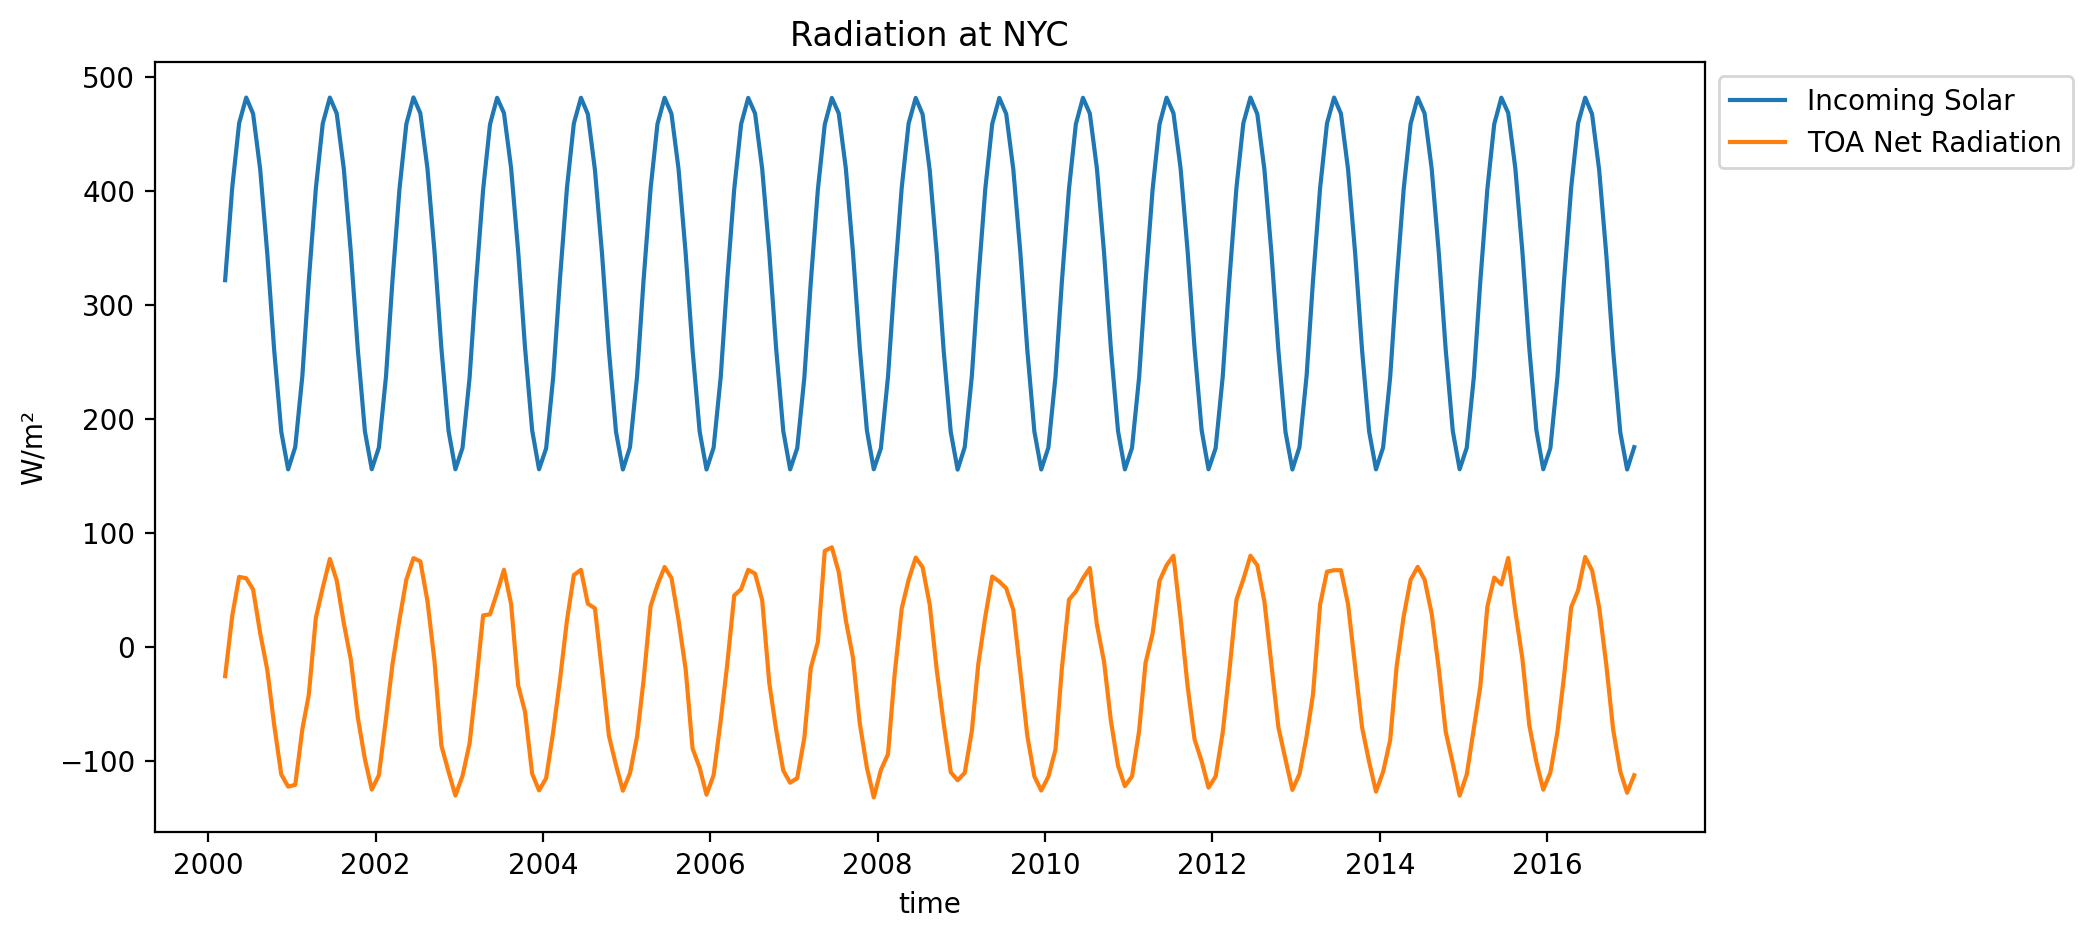

In [200]:
city = 'NYC'

plt.figure(figsize=(10,5))

cities['solar_mon'].sel(City=city).plot(label='Incoming Solar')
cities['toa_net_all_mon'].sel(City=city).plot(label='TOA Net Radiation')

plt.title(f'Radiation at {city}')
plt.ylabel('W/m²')
plt.legend(bbox_to_anchor=(1,1))

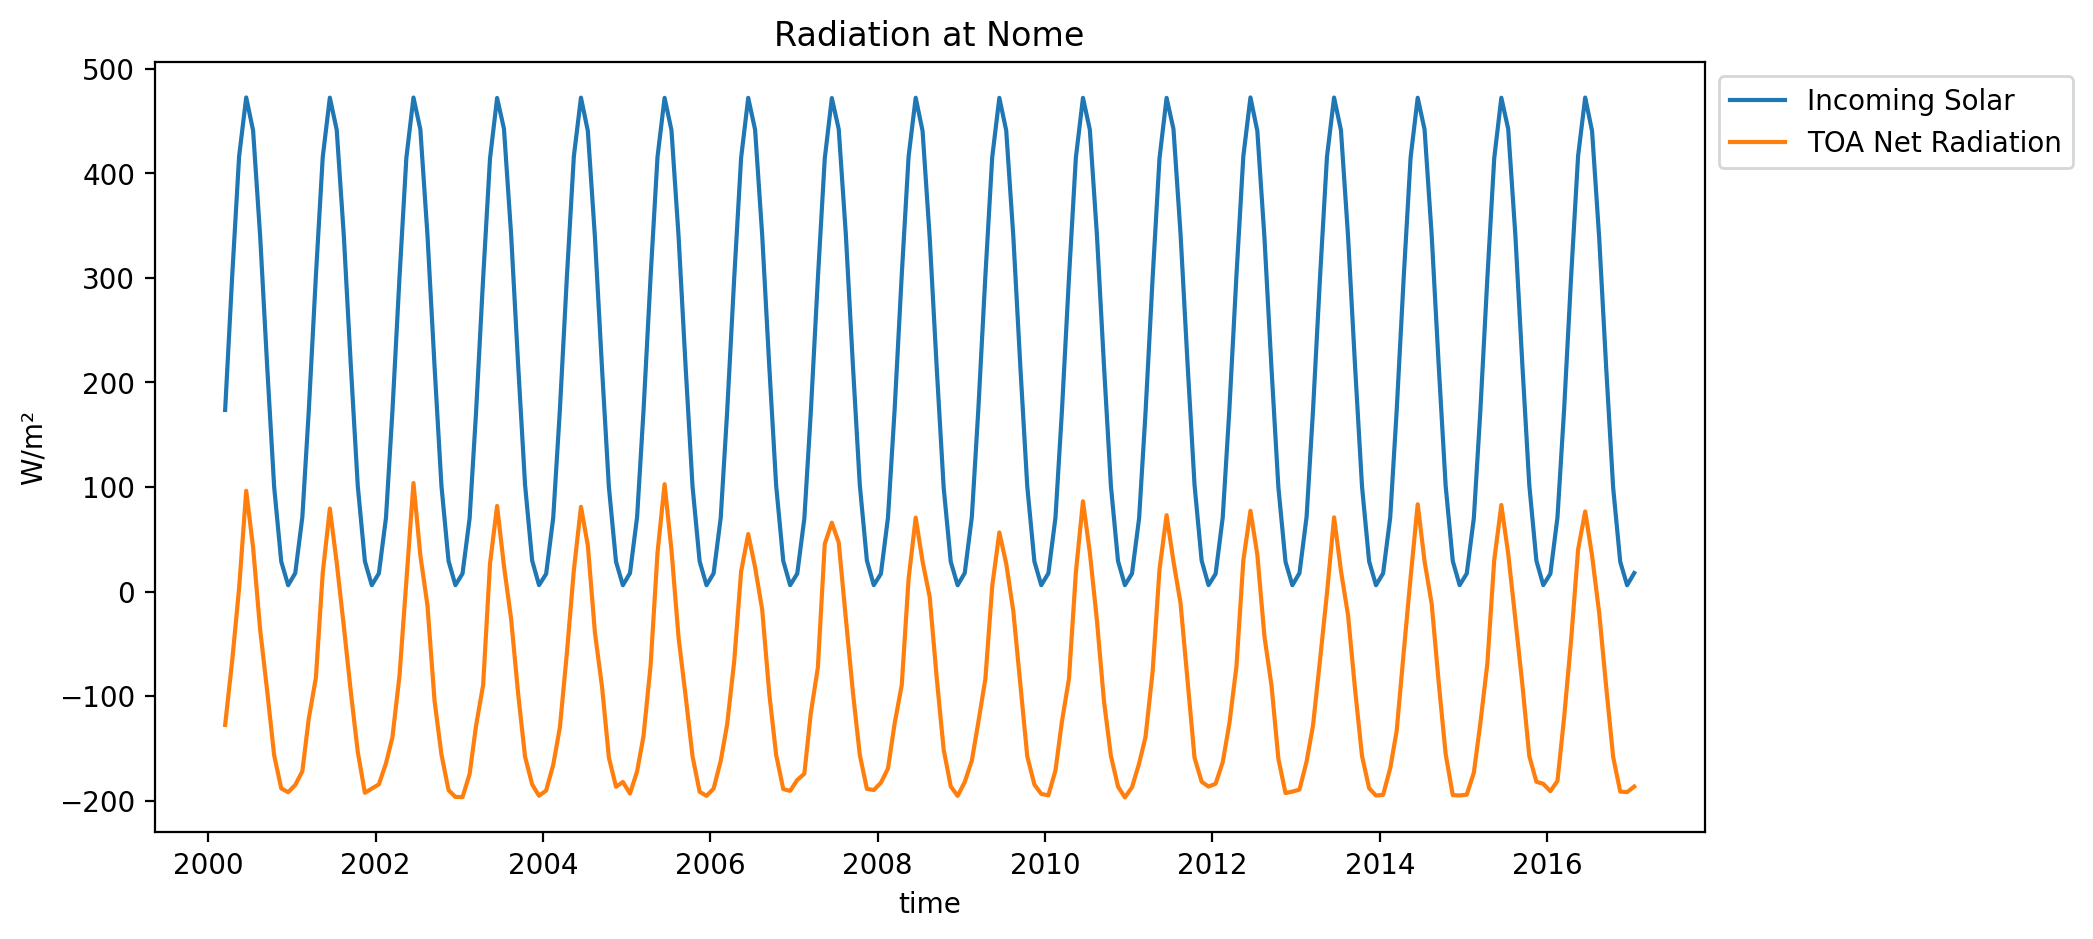

In [201]:
city = 'Nome'

plt.figure(figsize=(10,5))

cities['solar_mon'].sel(City=city).plot(label='Incoming Solar')
cities['toa_net_all_mon'].sel(City=city).plot(label='TOA Net Radiation')

plt.title(f'Radiation at {city}')
plt.ylabel('W/m²')
plt.legend(bbox_to_anchor=(1,1))

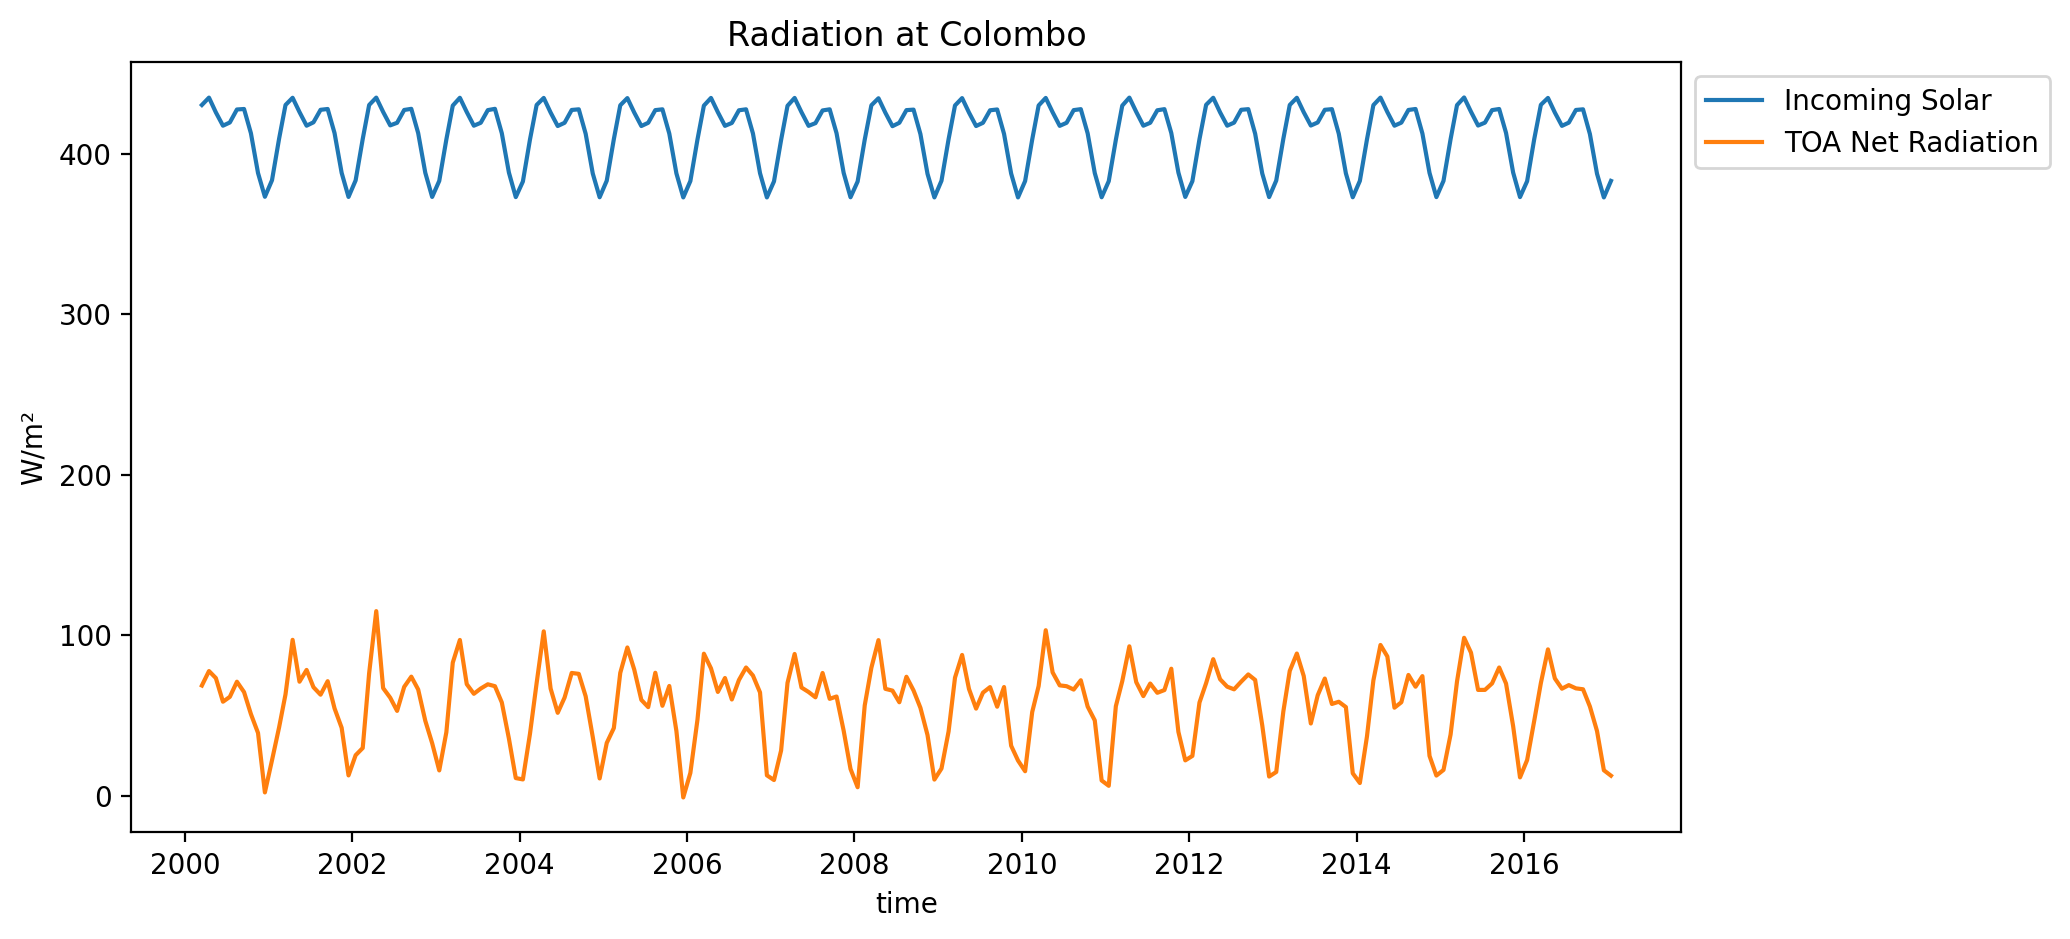

In [202]:
city = 'Colombo'

plt.figure(figsize=(10,5))

cities['solar_mon'].sel(City=city).plot(label='Incoming Solar')
cities['toa_net_all_mon'].sel(City=city).plot(label='TOA Net Radiation')

plt.title(f'Radiation at {city}')
plt.ylabel('W/m²')
plt.legend(bbox_to_anchor=(1,1))

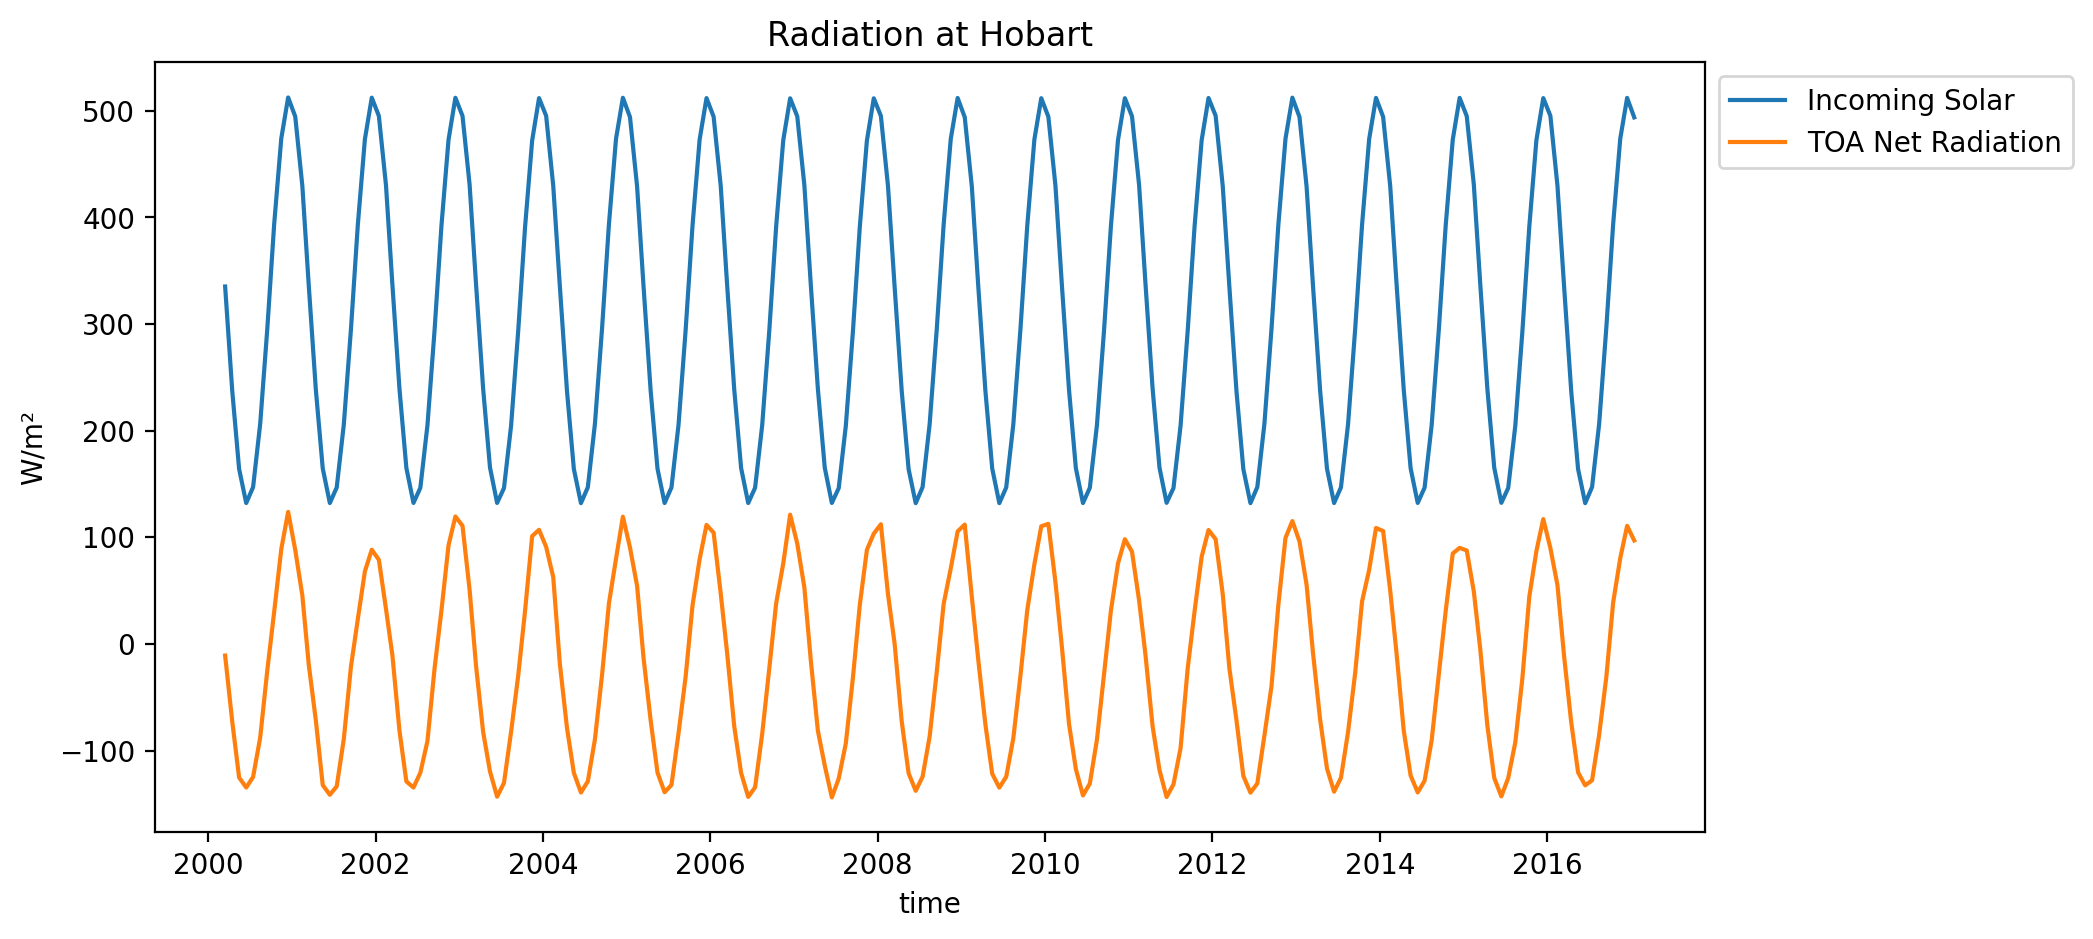

In [203]:
city = 'Hobart'

plt.figure(figsize=(10,5))

cities['solar_mon'].sel(City=city).plot(label='Incoming Solar')
cities['toa_net_all_mon'].sel(City=city).plot(label='TOA Net Radiation')

plt.title(f'Radiation at {city}')
plt.ylabel('W/m²')
plt.legend(bbox_to_anchor=(1,1))